Test Wallahi

In [1]:
#import the cleaned data.

#the real function will get the df fed as input from the clean function

import pandas as pd
import matplotlib.pyplot as plt
from clean_emi_data import clean_wholesale_price

save_path = 'data_output/wholesale_price_preprocessed.csv'

df = clean_wholesale_price()

Empty DataFrame
Columns: [el_price_dol/MWh_BEN2201, el_price_dol/MWh_HAY2201, el_price_dol/MWh_INV2201, el_price_dol/MWh_ISL2201, el_price_dol/MWh_KIK2201, el_price_dol/MWh_OTA2201, el_price_dol/MWh_RDF2201, el_price_dol/MWh_SFD2201, el_price_dol/MWh_WKM2201]
Index: []
✅ wholesale_price has been cleaned and saved under data_output/wholesale_price_utc12.csv ✅


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217390 entries, 0 to 217389
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   datetime                  217390 non-null  datetime64[ns]
 1   el_price_dol/MWh_BEN2201  217390 non-null  float64       
 2   el_price_dol/MWh_HAY2201  217390 non-null  float64       
 3   el_price_dol/MWh_INV2201  217390 non-null  float64       
 4   el_price_dol/MWh_ISL2201  217390 non-null  float64       
 5   el_price_dol/MWh_KIK2201  144357 non-null  float64       
 6   el_price_dol/MWh_OTA2201  217390 non-null  float64       
 7   el_price_dol/MWh_RDF2201  217390 non-null  float64       
 8   el_price_dol/MWh_SFD2201  217390 non-null  float64       
 9   el_price_dol/MWh_WKM2201  217390 non-null  float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 16.6 MB


In [3]:
df['hour_bucket'] = (
    df['datetime'] + pd.Timedelta(minutes=30)
).dt.floor('h')

df_hourly = (
    df
    .groupby('hour_bucket')
    .agg(
        datetime_utc12              = ('datetime',                    'max'),
        el_price_dol_MWh_BEN2201   = ('el_price_dol/MWh_BEN2201',   'mean'),
        el_price_dol_MWh_HAY2201   = ('el_price_dol/MWh_HAY2201',   'mean'),
        el_price_dol_MWh_INV2201   = ('el_price_dol/MWh_INV2201',   'mean'),
        el_price_dol_MWh_ISL2201   = ('el_price_dol/MWh_ISL2201',   'mean'),
        el_price_dol_MWh_KIK2201   = ('el_price_dol/MWh_KIK2201',   'mean'),
        el_price_dol_MWh_OTA2201   = ('el_price_dol/MWh_OTA2201',   'mean'),
        el_price_dol_MWh_RDF2201   = ('el_price_dol/MWh_RDF2201',   'mean'),
        el_price_dol_MWh_SFD2201   = ('el_price_dol/MWh_SFD2201',   'mean'),
        el_price_dol_MWh_WKM2201   = ('el_price_dol/MWh_WKM2201',   'mean'),
    )
    .reset_index(drop=True)
    .sort_values('datetime_utc12')
    .reset_index(drop=True)
)

In [4]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108709 entries, 0 to 108708
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   datetime_utc12            108709 non-null  datetime64[ns]
 1   el_price_dol_MWh_BEN2201  108709 non-null  float64       
 2   el_price_dol_MWh_HAY2201  108709 non-null  float64       
 3   el_price_dol_MWh_INV2201  108709 non-null  float64       
 4   el_price_dol_MWh_ISL2201  108709 non-null  float64       
 5   el_price_dol_MWh_KIK2201  72188 non-null   float64       
 6   el_price_dol_MWh_OTA2201  108709 non-null  float64       
 7   el_price_dol_MWh_RDF2201  108709 non-null  float64       
 8   el_price_dol_MWh_SFD2201  108709 non-null  float64       
 9   el_price_dol_MWh_WKM2201  108709 non-null  float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 8.3 MB


In [5]:
df_hourly.head()


,datetime_utc12,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201
0,2013-12-31 23:00:00,35.130,46.670,35.650,36.070,NaN,50.690,48.710,48.450,49.500
1,2014-01-01 00:00:00,33.755,34.900,34.265,34.720,NaN,37.845,36.420,36.195,36.865
2,2014-01-01 01:00:00,32.455,33.555,32.945,33.385,NaN,36.350,35.000,34.785,35.425
3,2014-01-01 02:00:00,5.555,5.745,5.635,5.710,NaN,6.215,5.975,5.950,6.050
4,2014-01-01 03:00:00,3.865,3.990,3.920,3.970,NaN,4.315,4.150,4.135,4.210


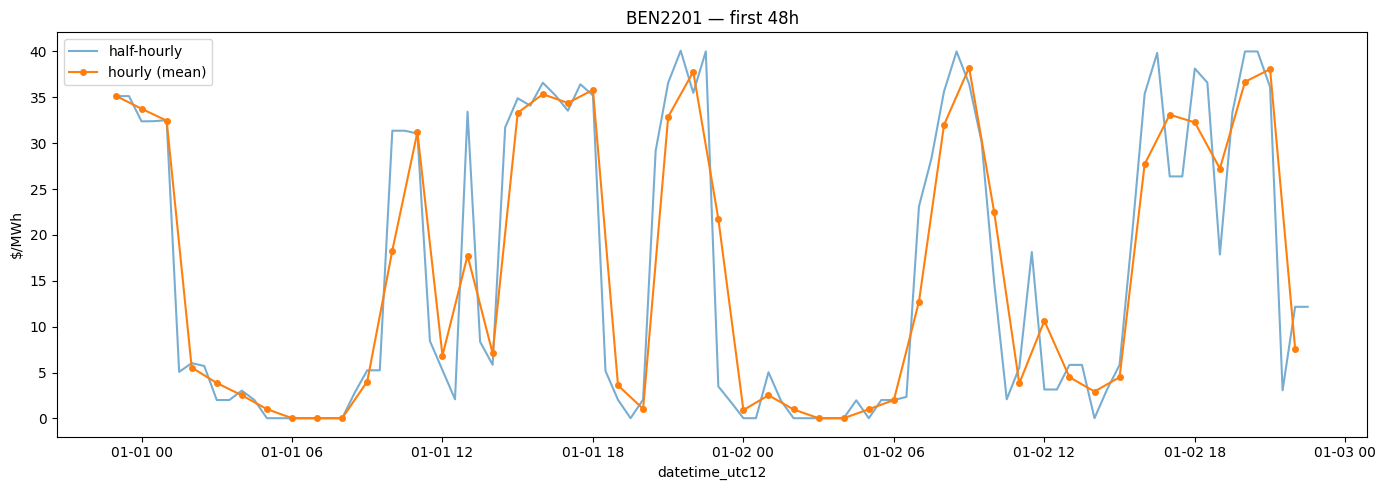

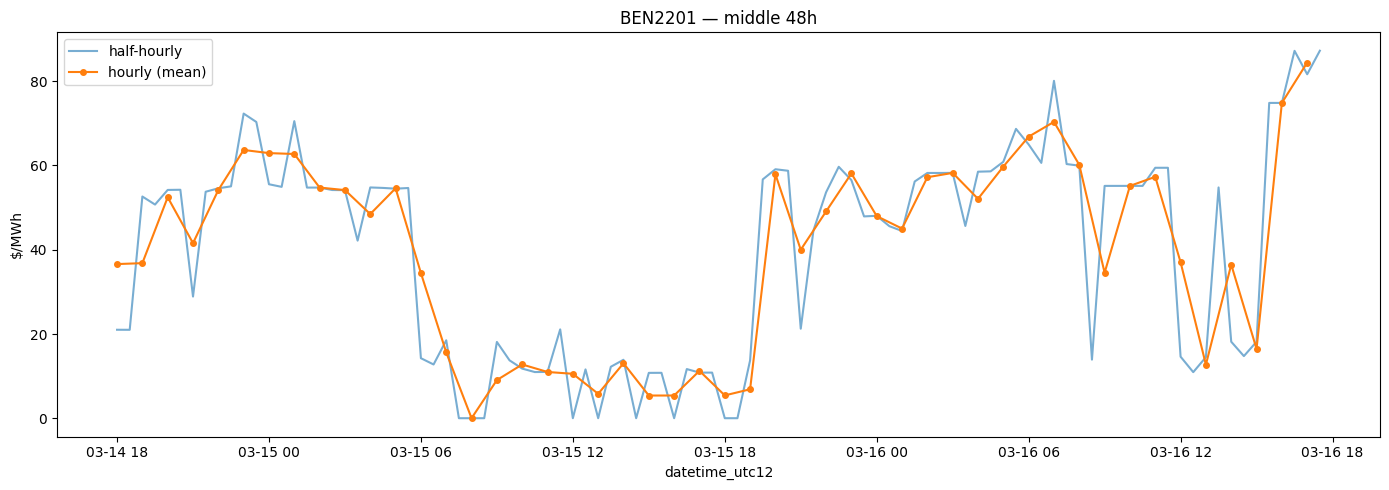

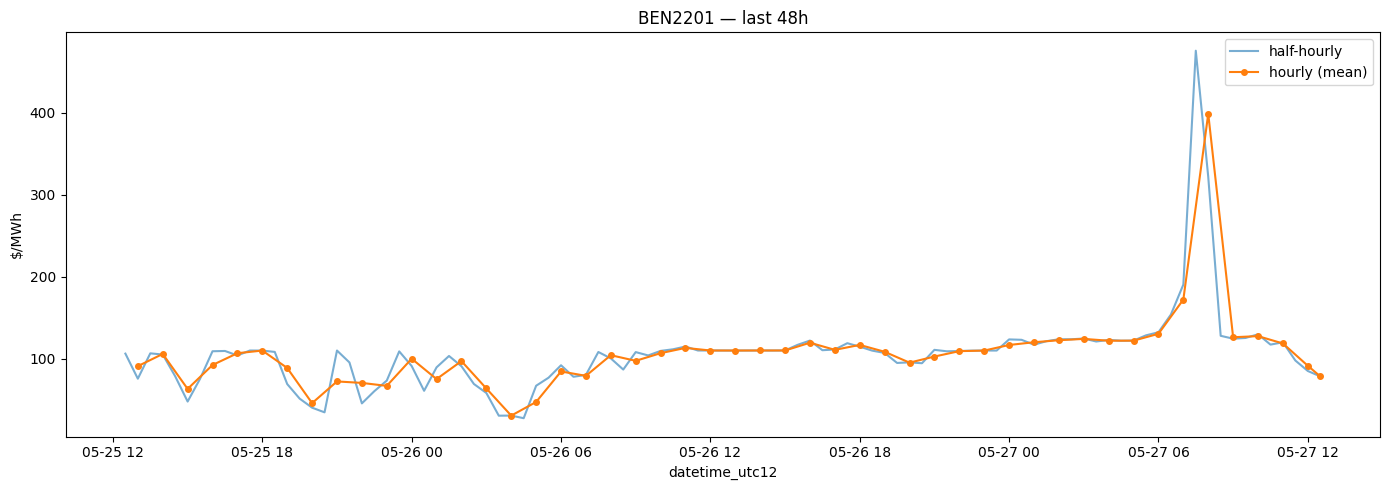

In [9]:
import matplotlib.pyplot as plt

col_hh = 'el_price_dol/MWh_BEN2201'
col_h  = 'el_price_dol_MWh_BEN2201'

def plot_window(label, mask_hh, mask_h):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df[mask_hh]['datetime'], df[mask_hh][col_hh], label='half-hourly', alpha=0.6)
    ax.plot(df_hourly[mask_h]['datetime_utc12'], df_hourly[mask_h][col_h], label='hourly (mean)', marker='o', markersize=4)
    ax.set_title(f'BEN2201 — {label}')
    ax.set_xlabel('datetime_utc12')
    ax.set_ylabel('$/MWh')
    ax.legend()
    plt.tight_layout()
    plt.show()

# First 48h
mask_hh_start = df['datetime'] < df['datetime'].min() + pd.Timedelta(hours=48)
mask_h_start  = df_hourly['datetime_utc12'] < df_hourly['datetime_utc12'].min() + pd.Timedelta(hours=48)

# Middle
mid_hh = df['datetime'].min() + (df['datetime'].max() - df['datetime'].min()) / 2
mid_h  = df_hourly['datetime_utc12'].min() + (df_hourly['datetime_utc12'].max() - df_hourly['datetime_utc12'].min()) / 2

mask_hh_mid = (df['datetime'] >= mid_hh) & (df['datetime'] < mid_hh + pd.Timedelta(hours=48))
mask_h_mid  = (df_hourly['datetime_utc12'] >= mid_h) & (df_hourly['datetime_utc12'] < mid_h + pd.Timedelta(hours=48))

# End
mask_hh_end = df['datetime'] >= df['datetime'].max() - pd.Timedelta(hours=48)
mask_h_end  = df_hourly['datetime_utc12'] >= df_hourly['datetime_utc12'].max() - pd.Timedelta(hours=48)

plot_window('first 48h',  mask_hh_start, mask_h_start)
plot_window('middle 48h', mask_hh_mid,   mask_h_mid)
plot_window('last 48h',   mask_hh_end,   mask_h_end)